# Loan Approval Prediction - CPE 232 Data Models

This notebook is a step-by-step Kaggle workflow for the **Loan Approval Prediction** competition.

---

**Notebook goals**
1. Load the competition data in a Kaggle-native way.
2. Validate the schema so we know training and submission logic are aligned.
3. Clean the raw columns and document what changed.
4. Run a real EDA section before modeling.
5. Train stronger CatBoost CV baselines with threshold tuning.
6. Export artifacts and a submission file using the new notebook slug.

## Workflow

We will move in the same order a human notebook usually does:

- setup packages and configuration
- resolve data paths and validate inputs
- inspect data quality and summarize cleaning actions
- run EDA and write down takeaways
- engineer stronger features
- compare feature bundles with CatBoost CV
- choose a threshold based on OOF F1
- export artifacts and prepare the submission file

In [1]:
# Cell: Setup — install missing packages, then import the notebook stack
import importlib.util
import subprocess
import sys


def run_cmd(cmd):
    print("Running:", " ".join(cmd))
    subprocess.check_call(cmd)


def ensure_package(module_name, package_name=None):
    pkg = package_name or module_name
    if importlib.util.find_spec(module_name) is None:
        run_cmd([sys.executable, "-m", "pip", "install", "-q", pkg])


ensure_package("numpy")
ensure_package("pandas")
ensure_package("matplotlib")
ensure_package("seaborn")
ensure_package("sklearn", "scikit-learn")
ensure_package("catboost")
ensure_package("kaggle")
ensure_package("dotenv", "python-dotenv")

In [2]:
# Cell: Imports — bring in all libraries used across EDA, training, and submission
import os
import time
import warnings
from datetime import UTC, datetime
from pathlib import Path
from zipfile import ZipFile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from catboost import CatBoostClassifier
from dotenv import load_dotenv
from IPython.display import display
from kaggle.api.kaggle_api_extended import KaggleApi
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

print("Imports ready.")

Imports ready.


## Notebook Config

This section keeps the same runtime surface as the fast notebook, so it still works well on Kaggle and still produces the same kinds of outputs. The difference is that we will inspect more before training.

In [ ]:
# Cell: Config — notebook identity, runtime flags, and competition schema
COMPETITION = "insurance-premium-prediction-cpe-232-data-models"
NOTEBOOK_SLUG = "loan23-03-human-eda-gpu-fast"

RUN_DOWNLOAD = True
RUN_SUBMISSION = True
FORCE_DOWNLOAD = True

CV_MODE = "stratified"
N_SPLITS = 5
SEED = 42
ENABLE_OPTUNA = False
ENABLE_ABLATIONS = True
ENABLE_ENSEMBLE = False

CATBOOST_ITERATIONS = 1500
EARLY_STOPPING_ROUNDS = 100
USE_GPU = True
GPU_DEVICE = "0"

ID_COL = "id"
TARGET_COL = "loan_status"
CATEGORICAL_COLS = ["education", "self_employed"]
NUMERIC_COLS = [
    "no_of_dependents",
    "income_annum",
    "loan_amount",
    "loan_term",
    "cibil_score",
    "residential_assets_value",
    "commercial_assets_value",
    "luxury_assets_value",
    "bank_asset_value",
]
MONEY_COLS = [
    "income_annum",
    "loan_amount",
    "residential_assets_value",
    "commercial_assets_value",
    "luxury_assets_value",
    "bank_asset_value",
]


def detect_gpu_available() -> bool:
    if not USE_GPU:
        return False
    try:
        proc = subprocess.run(
            ["nvidia-smi", "-L"],
            capture_output=True,
            text=True,
            timeout=5,
            check=False,
        )
        return proc.returncode == 0 and "GPU" in proc.stdout
    except Exception:
        return False


GPU_AVAILABLE = detect_gpu_available()
TRAIN_DEVICE_LABEL = "gpu" if GPU_AVAILABLE else "cpu"
OUTPUT_ROOT = (
    Path("/kaggle/working") if Path("/kaggle/working").exists() else Path.cwd()
)
ARTIFACT_DIR = OUTPUT_ROOT / "outputs"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print("Competition      :", COMPETITION)
print("Notebook slug    :", NOTEBOOK_SLUG)
print("Training device  :", TRAIN_DEVICE_LABEL)
print("CV mode / folds  :", CV_MODE, N_SPLITS)
print("Artifacts dir    :", ARTIFACT_DIR)

Competition      : insurance-premium-prediction-cpe-232-data-models
Notebook slug    : loan23-03-human-eda-gpu-fast
Training device  : gpu
CV mode / folds  : stratified 5
Artifacts dir    : /kaggle/working/outputs


## Data Resolution

We want one notebook that works in both places:

- locally, if the CSV files already exist in the project folder
- on Kaggle, if the competition files are mounted or need to be downloaded

That means we resolve the best available data path first, then validate the files before touching modeling code.

In [4]:
# Cell: Data access — resolve local or Kaggle data and authenticate if possible
def load_env_from_candidates():
    cwd = Path.cwd().resolve()
    candidates = [cwd / ".env", cwd.parent / ".env", Path("/kaggle/working/.env")]
    loaded = False
    for env_path in candidates:
        if env_path.exists():
            load_dotenv(env_path, override=False)
            print(f"Loaded env from {env_path}")
            loaded = True
            break
    if not loaded:
        print("No .env file found in default candidate locations.")


def resolve_local_data_dir() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [
        cwd / "data",
        cwd / "notebooks/2026-03-20-loan-approval-prediction-cpe-232-data-models/data",
        cwd.parent / "data",
    ]
    for c in candidates:
        if c.exists() and (c / "train.csv").exists() and (c / "test.csv").exists():
            return c
    return cwd / "data"


def resolve_kaggle_input_dir(competition: str) -> Path | None:
    direct = Path("/kaggle/input") / competition
    if direct.exists() and (direct / "train.csv").exists():
        return direct

    if Path("/kaggle/input").exists():
        matches = sorted(Path("/kaggle/input").glob(f"*{competition}*"))
        for m in matches:
            if (m / "train.csv").exists() and (m / "test.csv").exists():
                return m
    return None


def ensure_competition_data(
    api: KaggleApi | None, competition: str, run_download: bool, force_download: bool
):
    kaggle_input = resolve_kaggle_input_dir(competition)
    if kaggle_input is not None and not run_download:
        print("Using mounted Kaggle input:", kaggle_input)
        return kaggle_input

    local_data = resolve_local_data_dir()
    local_data.mkdir(parents=True, exist_ok=True)

    train_path = local_data / "train.csv"
    test_path = local_data / "test.csv"
    sample_path = local_data / "sample_submission.csv"
    have_local = train_path.exists() and test_path.exists() and sample_path.exists()

    if run_download:
        if api is None:
            if not have_local:
                raise RuntimeError(
                    "RUN_DOWNLOAD=True but Kaggle auth unavailable and no local data found."
                )
            print("RUN_DOWNLOAD=True but API unavailable. Falling back to local files.")
            return local_data

        if force_download and local_data.exists():
            for z in local_data.glob("*.zip"):
                try:
                    z.unlink()
                except Exception:
                    pass

        if force_download or not have_local:
            print("Downloading competition files via Kaggle API...")
            api.competition_download_files(
                competition, path=str(local_data), force=force_download, quiet=False
            )
            zip_candidates = sorted(local_data.glob("*.zip"))
            if not zip_candidates:
                raise RuntimeError("Kaggle download did not produce a zip file.")
            latest_zip = max(zip_candidates, key=lambda p: p.stat().st_mtime)
            with ZipFile(latest_zip, "r") as zf:
                zf.extractall(local_data)
            print("Extracted:", latest_zip.name)

        have_local = train_path.exists() and test_path.exists() and sample_path.exists()
        if not have_local:
            raise RuntimeError(f"Data missing after download in {local_data}")

    if not have_local:
        raise RuntimeError(
            f"Data not found. Checked local dir {local_data}. "
            "Set RUN_DOWNLOAD=True with valid Kaggle credentials or provide local CSV files."
        )

    return local_data


load_env_from_candidates()
os.environ.pop("KAGGLE_API_TOKEN", None)

api = None
try:
    api = KaggleApi()
    api.authenticate()
    print("Authenticated user:", api.get_config_value("username"))
except Exception as auth_exc:
    print("Kaggle auth unavailable:", auth_exc)

data_dir = ensure_competition_data(
    api=api,
    competition=COMPETITION,
    run_download=RUN_DOWNLOAD,
    force_download=FORCE_DOWNLOAD,
)
print("Resolved data dir:", data_dir)

No .env file found in default candidate locations.
Authenticated user: beambeambeam


100%|██████████| 1.24M/1.24M [00:00<00:00, 120MB/s]


Extracted: insurance-premium-prediction-cpe-232-data-models.zip
Resolved data dir: /kaggle/working/data


## Schema Validation

Before we clean or model anything, we verify that:

- train/test/sample files exist
- columns appear in the exact expected order
- numeric columns can be parsed
- the target is binary

This keeps downstream debugging much easier.

In [ ]:
# Cell: Load data — validate schema, parse numeric columns, and inspect the target
EXPECTED_TRAIN_COLUMNS = [
    "id",
    "no_of_dependents",
    "education",
    "self_employed",
    "income_annum",
    "loan_amount",
    "loan_term",
    "cibil_score",
    "residential_assets_value",
    "commercial_assets_value",
    "luxury_assets_value",
    "bank_asset_value",
    "loan_status",
]
EXPECTED_TEST_COLUMNS = [
    "id",
    "no_of_dependents",
    "education",
    "self_employed",
    "income_annum",
    "loan_amount",
    "loan_term",
    "cibil_score",
    "residential_assets_value",
    "commercial_assets_value",
    "luxury_assets_value",
    "bank_asset_value",
]


def fail_schema(message: str):
    raise ValueError(f"[SCHEMA ERROR] {message}")


def load_and_validate_data(data_dir: Path):
    train_path = data_dir / "train.csv"
    test_path = data_dir / "test.csv"
    sample_path = data_dir / "sample_submission.csv"

    if not train_path.exists() or not test_path.exists() or not sample_path.exists():
        fail_schema("Expected train.csv, test.csv, and sample_submission.csv to exist.")

    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)
    sample_df = pd.read_csv(sample_path)

    train_df.columns = [str(c).strip() for c in train_df.columns]
    test_df.columns = [str(c).strip() for c in test_df.columns]
    sample_df.columns = [str(c).strip() for c in sample_df.columns]

    if train_df.columns.tolist() != EXPECTED_TRAIN_COLUMNS:
        fail_schema(
            f"Unexpected train columns. expected={EXPECTED_TRAIN_COLUMNS}, got={train_df.columns.tolist()}"
        )
    if test_df.columns.tolist() != EXPECTED_TEST_COLUMNS:
        fail_schema(
            f"Unexpected test columns. expected={EXPECTED_TEST_COLUMNS}, got={test_df.columns.tolist()}"
        )
    if sample_df.columns.tolist() != [ID_COL, TARGET_COL]:
        fail_schema(
            f"Unexpected sample_submission columns. expected={[ID_COL, TARGET_COL]}, got={sample_df.columns.tolist()}"
        )

    train_features = [c for c in train_df.columns if c != TARGET_COL]
    if train_features != test_df.columns.tolist():
        fail_schema("Train/test feature mismatch after removing target column.")

    for col in NUMERIC_COLS + [TARGET_COL]:
        train_df[col] = pd.to_numeric(train_df[col], errors="coerce")
    for col in NUMERIC_COLS:
        test_df[col] = pd.to_numeric(test_df[col], errors="coerce")

    if not set(train_df[TARGET_COL].dropna().unique()).issubset({0, 1}):
        fail_schema("Target column must contain only 0/1 values.")

    print("Train shape :", train_df.shape)
    print("Test shape  :", test_df.shape)
    print("Sample shape:", sample_df.shape)
    print()
    print("Target balance:")
    display(
        train_df[TARGET_COL].value_counts(normalize=True).sort_index().rename("ratio")
    )

    return train_df, test_df, sample_df


train_df, test_df, sample_submission = load_and_validate_data(data_dir)
print("Schema ready.")

Train shape : (32000, 13)
Test shape  : (8000, 12)
Sample shape: (8000, 2)

Target balance:


loan_status
0   0.4553
1   0.5447
Name: ratio, dtype: float64

Schema ready.


## Data Cleaning Log

Now we inspect what needs normalization. Even if the dataset is already clean, it is still helpful to make the cleaning rules explicit so the feature pipeline is reproducible.

In [6]:
# Cell: Cleaning prep — normalize raw fields and record what changed
MISSING_TOKENS = {"", "na", "n/a", "none", "null", "nan", "unknown", "missing", "?"}


def normalize_text_like(series: pd.Series) -> pd.Series:
    s = series.astype("string").str.replace(r"\s+", " ", regex=True).str.strip()
    low = s.str.lower()
    return s.mask(low.isin(MISSING_TOKENS), pd.NA)


def robust_numeric(series: pd.Series) -> pd.Series:
    out = pd.to_numeric(series, errors="coerce")
    return out.replace([np.inf, -np.inf], np.nan)


def clean_base_frames(train_raw: pd.DataFrame, test_raw: pd.DataFrame):
    tr = train_raw.copy(deep=True)
    te = test_raw.copy(deep=True)

    for col in NUMERIC_COLS:
        tr[col] = robust_numeric(tr[col])
        te[col] = robust_numeric(te[col])

    tr[TARGET_COL] = robust_numeric(tr[TARGET_COL]).astype("int8")

    for col in CATEGORICAL_COLS:
        tr[col] = normalize_text_like(tr[col])
        te[col] = normalize_text_like(te[col])

    return tr, te


train_clean_base, test_clean_base = clean_base_frames(train_df, test_df)

cleaning_log = pd.DataFrame(
    [
        {
            "check": "missing_train_rows",
            "value": int(train_df.isna().any(axis=1).sum()),
            "notes": "Rows with at least one missing value in the training set.",
        },
        {
            "check": "missing_test_rows",
            "value": int(test_df.isna().any(axis=1).sum()),
            "notes": "Rows with at least one missing value in the test set.",
        },
        {
            "check": "train_duplicates",
            "value": int(train_df.duplicated().sum()),
            "notes": "Exact duplicate rows in train.",
        },
        {
            "check": "test_duplicates",
            "value": int(test_df.duplicated().sum()),
            "notes": "Exact duplicate rows in test.",
        },
        {
            "check": "normalized_categories",
            "value": len(CATEGORICAL_COLS),
            "notes": "Text columns trimmed, case-normalized, and missing-like tokens standardized.",
        },
    ]
)

display(cleaning_log)

missing_summary = pd.concat(
    [
        train_df.isna().sum().rename("missing_train"),
        train_df.isna().mean().mul(100).rename("missing_train_pct"),
        test_df.isna().sum().rename("missing_test"),
        test_df.isna().mean().mul(100).rename("missing_test_pct"),
    ],
    axis=1,
).sort_values(["missing_train", "missing_test"], ascending=False)

display(missing_summary)

,check,value,notes
0,missing_train_rows,17289,Rows with at least one missing value in the tr...
1,missing_test_rows,4348,Rows with at least one missing value in the te...
2,train_duplicates,0,Exact duplicate rows in train.
3,test_duplicates,0,Exact duplicate rows in test.
4,normalized_categories,2,"Text columns trimmed, case-normalized, and mis..."


,missing_train,missing_train_pct,missing_test,missing_test_pct
loan_amount,2918,9.1188,732.0000,9.1500
cibil_score,2770,8.6562,706.0000,8.8250
self_employed,2623,8.1969,652.0000,8.1500
residential_assets_value,2619,8.1844,694.0000,8.6750
income_annum,2135,6.6719,518.0000,6.4750
commercial_assets_value,2097,6.5531,489.0000,6.1125
bank_asset_value,1918,5.9937,475.0000,5.9375
loan_term,1897,5.9281,490.0000,6.1250
luxury_assets_value,1834,5.7313,487.0000,6.0875
education,1737,5.4281,455.0000,5.6875


## EDA — Overview

Before feature engineering, we want quick answers to a few practical questions:

- Is the target balanced or skewed?
- Are there obvious missing-value or duplicate issues?
- Which variables look most related to approval?
- Are any numeric features heavily skewed?

We will answer those with small, readable cells instead of one giant block.

In [ ]:
# Cell: EDA overview — shape, preview, target balance, duplicates, and summary statistics
print("Train preview:")
display(train_df.head())

print("Test preview:")
display(test_df.head())

overview_df = pd.DataFrame(
    {
        "dataset": ["train", "test"],
        "rows": [len(train_df), len(test_df)],
        "columns": [train_df.shape[1], test_df.shape[1]],
        "duplicate_rows": [
            int(train_df.duplicated().sum()),
            int(test_df.duplicated().sum()),
        ],
    }
)
display(overview_df)

target_summary = (
    train_df[TARGET_COL]
    .value_counts(dropna=False)
    .rename_axis(TARGET_COL)
    .rename("count")
    .reset_index()
)
target_summary["ratio"] = target_summary["count"] / target_summary["count"].sum()
display(target_summary)

numeric_summary = train_df[NUMERIC_COLS].describe().T
display(numeric_summary)

Train preview:


,id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,0.0000,Graduate,No,NaN,"7,271,300.0000",5.0000,622.0000,"6,572,296.0000","12,264,202.0000",NaN,"4,471,627.0000",0
1,2,2.0000,Not Graduate,Yes,"2,832,292.0000",NaN,9.0000,482.0000,"3,274,507.0000","16,079,677.0000","2,643,225.0000","3,021,958.0000",1
2,3,2.0000,Graduate,No,"2,594,879.0000","8,265,934.0000",16.0000,786.0000,"179,550.0000","1,361,037.0000","9,057,816.0000",NaN,0
3,4,4.0000,Graduate,No,"2,497,120.0000","26,116,812.0000",16.0000,352.0000,"16,697,499.0000",NaN,0.0000,"983,214.0000",0
4,5,5.0000,Not Graduate,Yes,NaN,"4,071,241.0000",19.0000,381.0000,NaN,"2,788,429.0000","7,977,004.0000","11,154,770.0000",1


Test preview:


,id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
0,32001,1.0000,Graduate,Yes,"1,184,682.0000","17,119,708.0000",11.0000,749.0000,0.0000,"4,800,216.0000","16,565,306.0000","1,631,095.0000"
1,32002,0.0000,Graduate,No,"8,920,224.0000","5,040,529.0000",0.0000,989.0000,NaN,"3,590,433.0000","22,490,251.0000","4,153,781.0000"
2,32003,0.0000,Not Graduate,Yes,"9,064,660.0000","15,390,179.0000",14.0000,511.0000,"1,254,869.0000","6,981,191.0000","12,755,544.0000","1,497,759.0000"
3,32004,5.0000,Graduate,No,"9,787,483.0000","5,649,434.0000",NaN,513.0000,"1,315,339.0000","421,501.0000","21,345,655.0000","945,687.0000"
4,32005,1.0000,Not Graduate,No,"320,746.0000","2,157,362.0000",13.0000,759.0000,"3,273,669.0000","2,587,980.0000","25,049,850.0000","1,374,027.0000"


,dataset,rows,columns,duplicate_rows
0,train,32000,13,0
1,test,8000,12,0


,loan_status,count,ratio
0,1,17430,0.5447
1,0,14570,0.4553


,count,mean,std,min,25%,50%,75%,max
no_of_dependents,"30,395.0000",1.9519,1.6312,0.0000,0.0000,2.0000,3.0000,5.0000
income_annum,"29,865.0000","3,523,465.8867","2,920,311.3126",0.0000,"830,284.0000","2,961,480.0000","5,827,615.0000","11,369,423.0000"
loan_amount,"29,082.0000","12,851,018.5821","9,177,296.6448",0.0000,"5,416,666.0000","11,746,169.0000","18,701,166.0000","46,044,308.0000"
loan_term,"30,103.0000",12.3672,5.4403,0.0000,9.0000,13.0000,17.0000,22.0000
cibil_score,"29,230.0000",661.7312,173.0936,223.0000,529.0000,663.5000,811.0000,"1,011.0000"
residential_assets_value,"29,381.0000","3,956,637.7345","5,339,316.2166",0.0000,0.0000,"1,812,942.0000","5,528,413.0000","34,562,020.0000"
commercial_assets_value,"29,903.0000","6,212,830.1276","5,490,717.1960",0.0000,"1,880,555.0000","4,531,977.0000","9,059,979.5000","24,041,102.0000"
luxury_assets_value,"30,166.0000","11,195,238.6189","8,793,568.2731",0.0000,"4,067,125.2500","9,802,424.5000","16,711,702.7500","46,505,087.0000"
bank_asset_value,"30,082.0000","4,702,795.4577","3,770,260.7589",0.0000,"1,596,127.2500","3,998,887.5000","7,027,443.7500","17,479,340.0000"


Column: education


,education,count,approval_rate
0,<NA>,1737,0.5527
1,Not Graduate,16081,0.5451
2,Graduate,14182,0.5433


Column: self_employed


,self_employed,count,approval_rate
0,<NA>,2623,0.5505
1,Yes,15939,0.5473
2,No,13438,0.5404


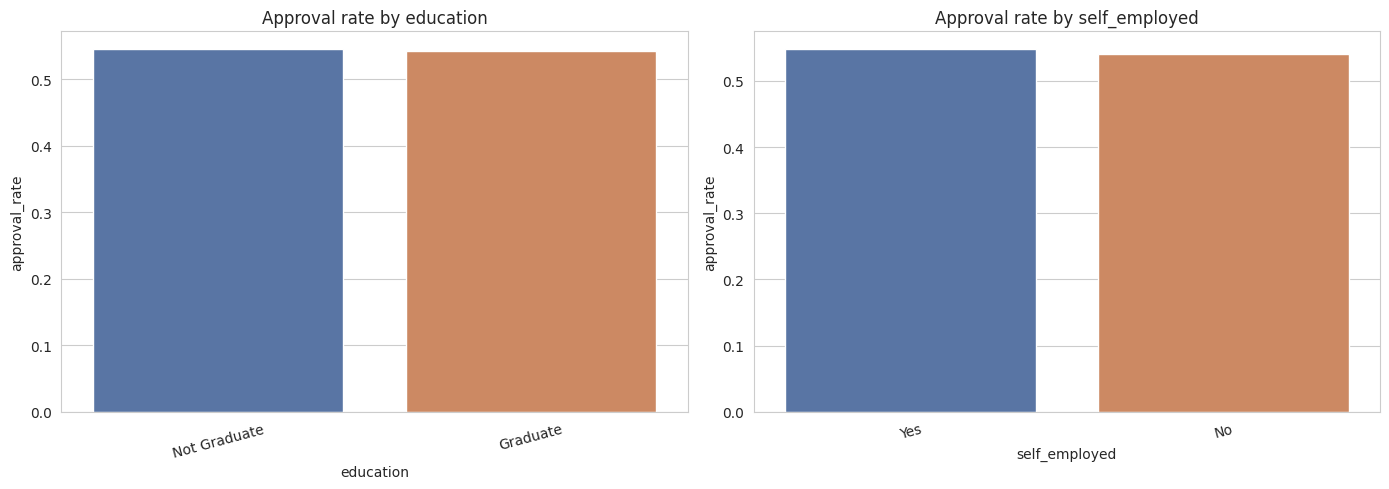

In [8]:
# Cell: EDA categorical review — category mix and approval rate by category
for col in CATEGORICAL_COLS:
    print(f"Column: {col}")
    count_df = (
        train_clean_base.groupby(col, dropna=False)[TARGET_COL]
        .agg(["count", "mean"])
        .rename(columns={"mean": "approval_rate"})
        .sort_values(["approval_rate", "count"], ascending=[False, False])
        .reset_index()
    )
    display(count_df)

fig, axes = plt.subplots(1, len(CATEGORICAL_COLS), figsize=(14, 5))
if len(CATEGORICAL_COLS) == 1:
    axes = [axes]

for ax, col in zip(axes, CATEGORICAL_COLS):
    rate_df = (
        train_clean_base.groupby(col, dropna=False)[TARGET_COL]
        .mean()
        .sort_values(ascending=False)
        .rename("approval_rate")
        .reset_index()
    )
    sns.barplot(data=rate_df, x=col, y="approval_rate", ax=ax, palette="deep")
    ax.set_title(f"Approval rate by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("approval_rate")
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

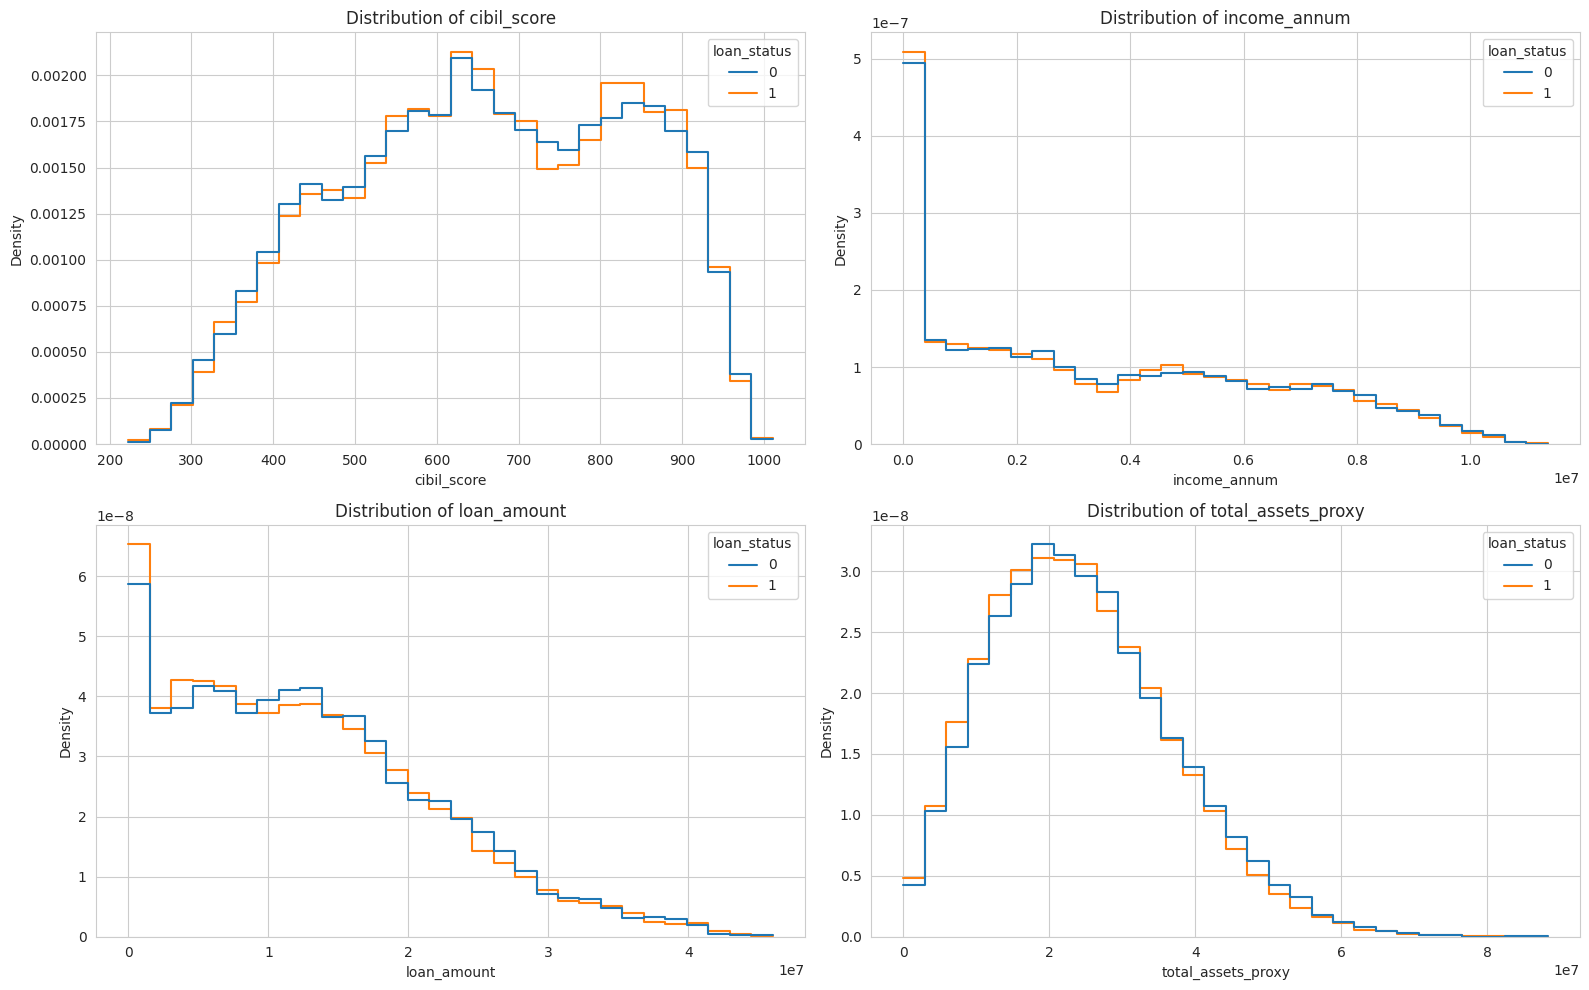

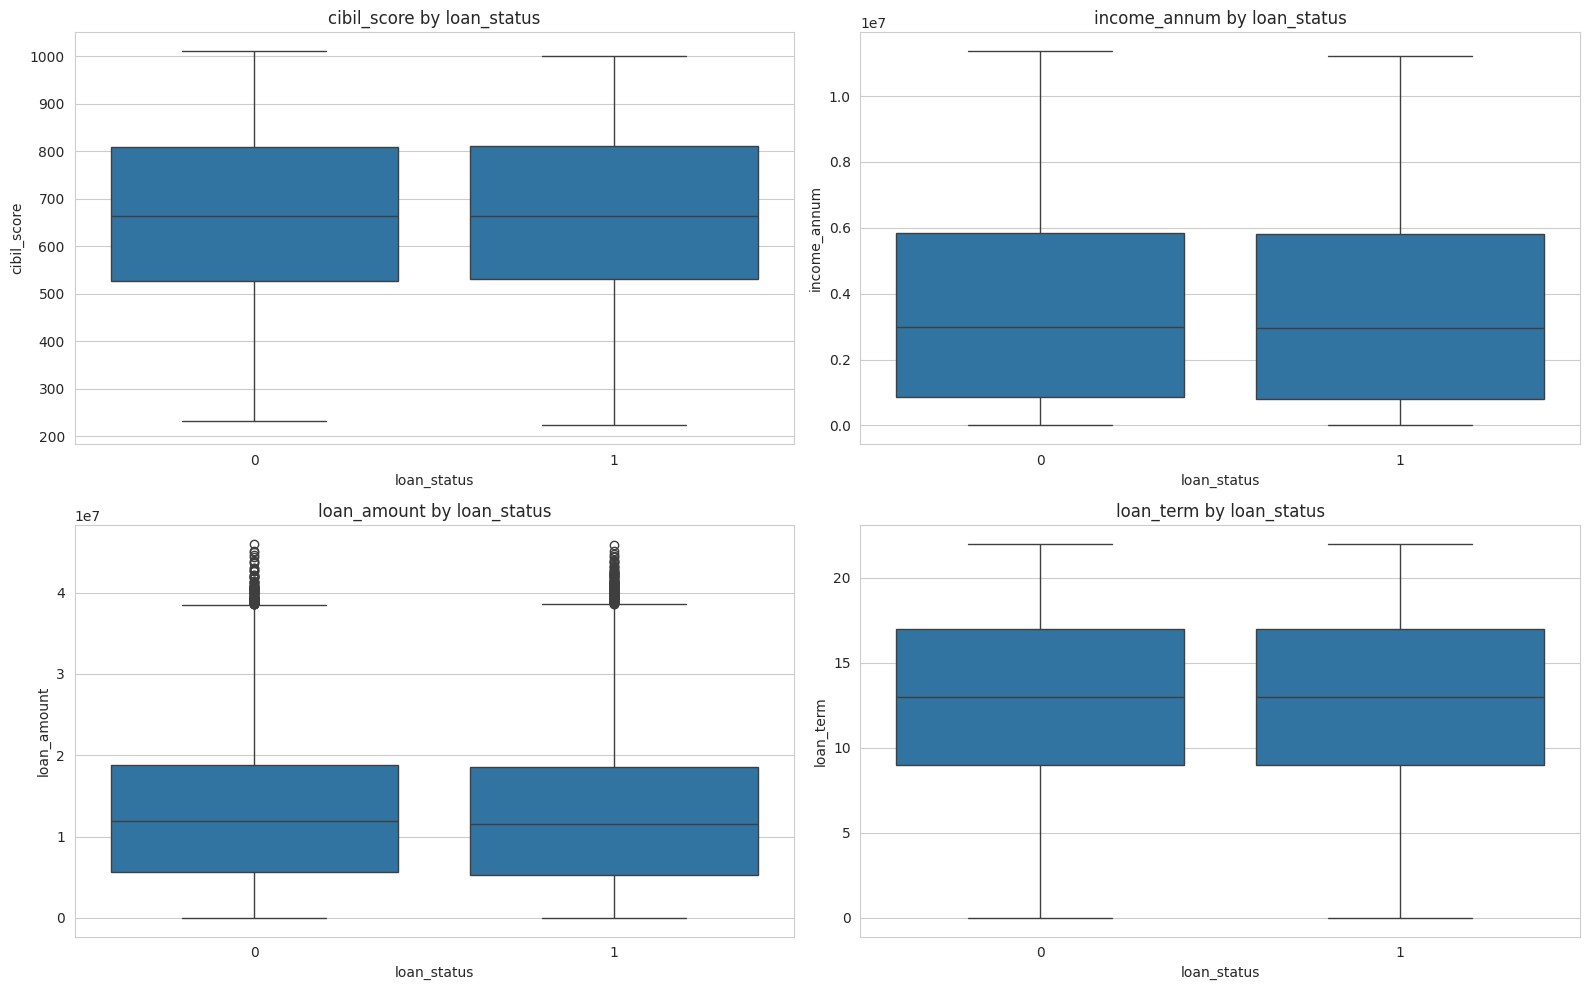

In [9]:
# Cell: EDA numeric distributions — inspect scale, skew, and approval separation
plot_cols = ["cibil_score", "income_annum", "loan_amount", "total_assets_proxy"]
plot_df = train_clean_base.copy()
plot_df["total_assets_proxy"] = (
    plot_df["residential_assets_value"].fillna(0)
    + plot_df["commercial_assets_value"].fillna(0)
    + plot_df["luxury_assets_value"].fillna(0)
    + plot_df["bank_asset_value"].fillna(0)
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, col in zip(axes.flatten(), plot_cols):
    sns.histplot(
        data=plot_df,
        x=col,
        hue=TARGET_COL,
        bins=30,
        stat="density",
        common_norm=False,
        element="step",
        fill=False,
        ax=ax,
    )
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

box_cols = ["cibil_score", "income_annum", "loan_amount", "loan_term"]
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, col in zip(axes.flatten(), box_cols):
    sns.boxplot(data=train_clean_base, x=TARGET_COL, y=col, ax=ax)
    ax.set_title(f"{col} by loan_status")
plt.tight_layout()
plt.show()

,cibil_band_preview,approval_rate
0,very_low,0.5396
1,low,0.5467
2,mid,0.5445
3,high,0.5496
4,very_high,0.5471
5,NaN,0.5372


,loan_to_income_bucket,approval_rate
0,"(-0.001, 1.963]",0.5541
1,"(1.963, 3.101]",0.5477
2,"(3.101, 5.041]",0.5337
3,"(5.041, 37754.78]",0.5357


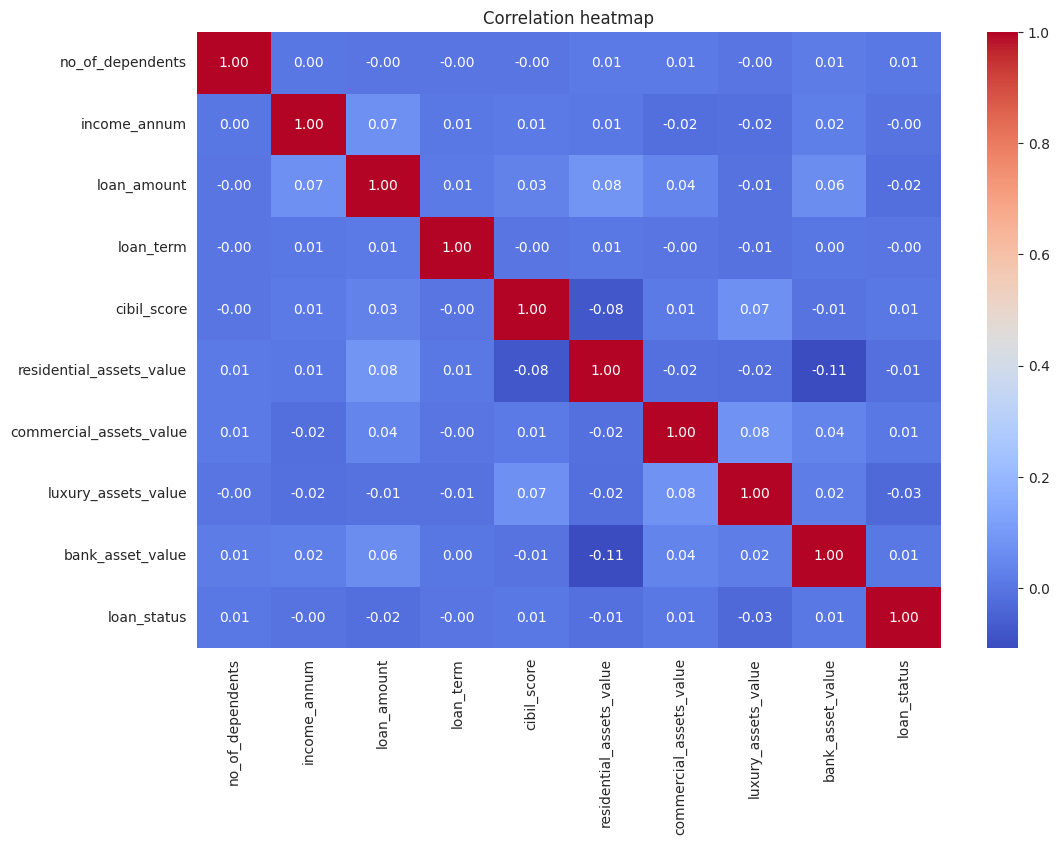

,takeaway,detail
0,credit_score_signal,CIBIL score shows a strong directional relatio...
1,scale_skew,"Income, loan amount, and asset values are skew..."
2,ratio_features,Loan-to-income and asset-to-loan style ratios ...


In [ ]:
# Cell: EDA relationships — approval rates across buckets and numeric correlation
bucket_df = train_clean_base.copy()
bucket_df["cibil_band_preview"] = pd.cut(
    bucket_df["cibil_score"],
    bins=[-np.inf, 500, 650, 750, 850, np.inf],
    labels=["very_low", "low", "mid", "high", "very_high"],
)
bucket_df["loan_to_income_preview"] = bucket_df["loan_amount"] / bucket_df[
    "income_annum"
].replace(0, np.nan)
bucket_df["loan_to_income_bucket"] = pd.qcut(
    bucket_df["loan_to_income_preview"].fillna(
        bucket_df["loan_to_income_preview"].median()
    ),
    q=4,
    duplicates="drop",
)

approval_by_band = (
    bucket_df.groupby("cibil_band_preview", dropna=False)[TARGET_COL]
    .mean()
    .rename("approval_rate")
    .reset_index()
)
display(approval_by_band)

approval_by_ratio = (
    bucket_df.groupby("loan_to_income_bucket", dropna=False)[TARGET_COL]
    .mean()
    .rename("approval_rate")
    .reset_index()
)
display(approval_by_ratio)

corr_cols = NUMERIC_COLS + [TARGET_COL]
corr_df = train_df[corr_cols].corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(corr_df, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation heatmap")
plt.show()

eda_takeaways = pd.DataFrame(
    [
        {
            "takeaway": "credit_score_signal",
            "detail": "CIBIL score shows a strong directional relationship with approval and deserves both raw and bucketed treatment.",
        },
        {
            "takeaway": "scale_skew",
            "detail": "Income, loan amount, and asset values are skewed, so log features should help the model.",
        },
        {
            "takeaway": "ratio_features",
            "detail": "Loan-to-income and asset-to-loan style ratios look meaningful for separating approved vs rejected applications.",
        },
    ]
)
display(eda_takeaways)

## Feature Engineering

Now we turn the EDA observations into reusable feature bundles. We keep the same three variants from the fast notebook:

- `raw_minimal`
- `processed_basic`
- `processed_extended`

That lets us compare how much value each layer of feature work adds.

In [ ]:
# Cell: Feature engineering helpers — imputation, indicators, ratios, logs, and category typing
FEATURE_CACHE = {}


def fill_numeric_median(tr: pd.DataFrame, te: pd.DataFrame, columns: list[str]):
    for col in columns:
        med = float(tr[col].median()) if tr[col].notna().any() else 0.0
        tr[col] = tr[col].fillna(med)
        te[col] = te[col].fillna(med)


def fill_categorical_missing(tr: pd.DataFrame, te: pd.DataFrame, columns: list[str]):
    for col in columns:
        tr[col] = tr[col].fillna("Missing").astype("string")
        te[col] = te[col].fillna("Missing").astype("string")

        vocab = sorted(set(tr[col].dropna().astype(str).unique()))
        if "Unknown" not in vocab:
            vocab.append("Unknown")
        tr[col] = tr[col].where(tr[col].isin(vocab), "Unknown")
        te[col] = te[col].where(te[col].isin(vocab), "Unknown")


def add_missing_indicators(tr: pd.DataFrame, te: pd.DataFrame, columns: list[str]):
    created = []
    for col in columns:
        if tr[col].isna().mean() <= 0:
            continue
        name = f"mis_{col}"
        tr[name] = tr[col].isna().astype("int8")
        te[name] = te[col].isna().astype("int8")
        created.append(name)
    return created


def add_extended_features(tr: pd.DataFrame, te: pd.DataFrame):
    asset_cols = [
        "residential_assets_value",
        "commercial_assets_value",
        "luxury_assets_value",
        "bank_asset_value",
    ]

    tr["total_assets"] = tr[asset_cols].sum(axis=1)
    te["total_assets"] = te[asset_cols].sum(axis=1)

    loan_safe_tr = tr["loan_amount"].replace(0, np.nan)
    loan_safe_te = te["loan_amount"].replace(0, np.nan)
    income_safe_tr = tr["income_annum"].replace(0, np.nan)
    income_safe_te = te["income_annum"].replace(0, np.nan)
    term_safe_tr = tr["loan_term"].replace(0, np.nan)
    term_safe_te = te["loan_term"].replace(0, np.nan)

    tr["total_assets_to_loan"] = (tr["total_assets"] / loan_safe_tr).replace(
        [np.inf, -np.inf], np.nan
    )
    te["total_assets_to_loan"] = (te["total_assets"] / loan_safe_te).replace(
        [np.inf, -np.inf], np.nan
    )
    tr["income_to_loan"] = (tr["income_annum"] / loan_safe_tr).replace(
        [np.inf, -np.inf], np.nan
    )
    te["income_to_loan"] = (te["income_annum"] / loan_safe_te).replace(
        [np.inf, -np.inf], np.nan
    )
    tr["loan_to_income"] = (tr["loan_amount"] / income_safe_tr).replace(
        [np.inf, -np.inf], np.nan
    )
    te["loan_to_income"] = (te["loan_amount"] / income_safe_te).replace(
        [np.inf, -np.inf], np.nan
    )
    tr["loan_per_term"] = (tr["loan_amount"] / term_safe_tr).replace(
        [np.inf, -np.inf], np.nan
    )
    te["loan_per_term"] = (te["loan_amount"] / term_safe_te).replace(
        [np.inf, -np.inf], np.nan
    )
    tr["income_per_dependent"] = tr["income_annum"] / (
        tr["no_of_dependents"].fillna(0) + 1.0
    )
    te["income_per_dependent"] = te["income_annum"] / (
        te["no_of_dependents"].fillna(0) + 1.0
    )
    tr["assets_minus_loan"] = tr["total_assets"] - tr["loan_amount"].fillna(0)
    te["assets_minus_loan"] = te["total_assets"] - te["loan_amount"].fillna(0)

    total_assets_safe_tr = tr["total_assets"].replace(0, np.nan)
    total_assets_safe_te = te["total_assets"].replace(0, np.nan)
    for col in asset_cols:
        ratio_name = f"{col}_share"
        tr[ratio_name] = (tr[col] / total_assets_safe_tr).replace(
            [np.inf, -np.inf], np.nan
        )
        te[ratio_name] = (te[col] / total_assets_safe_te).replace(
            [np.inf, -np.inf], np.nan
        )

    for col in MONEY_COLS + ["total_assets"]:
        tr[f"log1p_{col}"] = np.log1p(np.clip(tr[col].fillna(0), a_min=0, a_max=None))
        te[f"log1p_{col}"] = np.log1p(np.clip(te[col].fillna(0), a_min=0, a_max=None))

    tr["cibil_band"] = pd.cut(
        tr["cibil_score"],
        bins=[-np.inf, 500, 650, 750, 850, np.inf],
        labels=["very_low", "low", "mid", "high", "very_high"],
    ).astype("string")
    te["cibil_band"] = pd.cut(
        te["cibil_score"],
        bins=[-np.inf, 500, 650, 750, 850, np.inf],
        labels=["very_low", "low", "mid", "high", "very_high"],
    ).astype("string")


def finalize_frame_types(tr: pd.DataFrame, te: pd.DataFrame, feature_cols: list[str]):
    cat_cols = []
    for col in feature_cols:
        if str(tr[col].dtype) in {"object", "string", "category"}:
            tr[col] = tr[col].astype("string")
            te[col] = te[col].astype("string")
            cat_cols.append(col)
        else:
            tr[col] = robust_numeric(tr[col]).astype("float32")
            te[col] = robust_numeric(te[col]).astype("float32")
    return cat_cols


def build_features(variant: str, train_raw: pd.DataFrame, test_raw: pd.DataFrame):
    if variant not in {"raw_minimal", "processed_basic", "processed_extended"}:
        raise ValueError(f"Unknown feature variant: {variant}")

    tr, te = clean_base_frames(train_raw, test_raw)

    if variant == "raw_minimal":
        fill_numeric_median(tr, te, NUMERIC_COLS)
        fill_categorical_missing(tr, te, CATEGORICAL_COLS)
    elif variant == "processed_basic":
        add_missing_indicators(tr, te, NUMERIC_COLS + CATEGORICAL_COLS)
        fill_numeric_median(tr, te, NUMERIC_COLS)
        fill_categorical_missing(tr, te, CATEGORICAL_COLS)
    elif variant == "processed_extended":
        add_missing_indicators(tr, te, NUMERIC_COLS + CATEGORICAL_COLS)
        fill_numeric_median(tr, te, NUMERIC_COLS)
        fill_categorical_missing(tr, te, CATEGORICAL_COLS)
        add_extended_features(tr, te)

    feature_cols = [c for c in tr.columns if c not in {ID_COL, TARGET_COL}]
    cat_cols = finalize_frame_types(tr, te, feature_cols)
    meta = {"feature_cols": feature_cols, "cat_cols": cat_cols}
    return tr, te, meta


def get_feature_bundle(feature_variant: str):
    if feature_variant not in FEATURE_CACHE:
        FEATURE_CACHE[feature_variant] = build_features(
            feature_variant, train_df, test_df
        )
        print(f"[cache] built features for {feature_variant}")
    return FEATURE_CACHE[feature_variant]

In [12]:
# Cell: Feature bundle preview — compare the three variants before training
feature_preview_rows = []
for variant in ["raw_minimal", "processed_basic", "processed_extended"]:
    tr_variant, te_variant, meta_variant = get_feature_bundle(variant)
    feature_preview_rows.append(
        {
            "variant": variant,
            "train_rows": len(tr_variant),
            "test_rows": len(te_variant),
            "feature_count": len(meta_variant["feature_cols"]),
            "categorical_feature_count": len(meta_variant["cat_cols"]),
        }
    )

feature_preview_df = pd.DataFrame(feature_preview_rows)
display(feature_preview_df)

preview_train, _, preview_meta = get_feature_bundle("processed_extended")
display(preview_train[preview_meta["feature_cols"][:12]].head())

[cache] built features for raw_minimal
[cache] built features for processed_basic
[cache] built features for processed_extended


,variant,train_rows,test_rows,feature_count,categorical_feature_count
0,raw_minimal,32000,8000,11,2
1,processed_basic,32000,8000,22,2
2,processed_extended,32000,8000,41,3


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,mis_no_of_dependents
0,0.0000,Graduate,No,"2,961,480.0000","7,271,300.0000",5.0000,622.0000,"6,572,296.0000","12,264,202.0000","9,802,424.0000","4,471,627.0000",0.0000
1,2.0000,Not Graduate,Yes,"2,832,292.0000","11,746,169.0000",9.0000,482.0000,"3,274,507.0000","16,079,677.0000","2,643,225.0000","3,021,958.0000",0.0000
2,2.0000,Graduate,No,"2,594,879.0000","8,265,934.0000",16.0000,786.0000,"179,550.0000","1,361,037.0000","9,057,816.0000","3,998,887.5000",0.0000
3,4.0000,Graduate,No,"2,497,120.0000","26,116,812.0000",16.0000,352.0000,"16,697,499.0000","4,531,977.0000",0.0000,"983,214.0000",0.0000
4,5.0000,Not Graduate,Yes,"2,961,480.0000","4,071,241.0000",19.0000,381.0000,"1,812,942.0000","2,788,429.0000","7,977,004.0000","11,154,770.0000",0.0000


## Fold Setup

We use stratified CV because the evaluation metric is F1 on a binary target, so keeping the class balance stable across folds is a good default.

In [ ]:
# Cell: Fold setup — create stratified folds and save fold assignments
def make_folds(y: pd.Series, n_splits: int, seed: int):
    idx = np.arange(len(y))
    splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    folds = []
    for tr_idx, va_idx in splitter.split(idx, y):
        folds.append((tr_idx, va_idx))

    fold_id = np.full(len(y), -1, dtype=np.int16)
    for fold, (_, va_idx) in enumerate(folds):
        fold_id[va_idx] = fold
    if (fold_id < 0).any():
        raise RuntimeError("Some rows were not assigned to folds.")
    return folds, fold_id


FOLDS, FOLD_ID = make_folds(train_df[TARGET_COL], N_SPLITS, SEED)
fold_index_path = ARTIFACT_DIR / f"fold_indices_{NOTEBOOK_SLUG}.csv"
pd.DataFrame({ID_COL: train_df[ID_COL], "fold_id": FOLD_ID}).to_csv(
    fold_index_path, index=False
)

display(pd.Series(FOLD_ID).value_counts().sort_index().rename("rows_per_fold"))
print("Saved fold assignments to", fold_index_path)

0    6400
1    6400
2    6400
3    6400
4    6400
Name: rows_per_fold, dtype: int64

Saved fold assignments to /kaggle/working/outputs/fold_indices_loan23-03-human-eda-gpu-fast.csv


## Modeling

This is the stronger part of the notebook. We keep the same CatBoost training flow from `loan23-02`, but show it more clearly:

- build the model
- fit each fold
- collect OOF and test predictions
- compare ablations
- search for the best threshold for F1

In [ ]:
# Cell: Modeling helpers — train CatBoost, collect fold predictions, and summarize experiments
def build_model(
    seed: int, params_override: dict | None = None, force_cpu: bool = False
):
    params_override = params_override or {}
    use_gpu = USE_GPU and GPU_AVAILABLE and not force_cpu
    base = {
        "loss_function": "Logloss",
        "eval_metric": "F1",
        "learning_rate": 0.03,
        "depth": 8,
        "l2_leaf_reg": 5.0,
        "iterations": CATBOOST_ITERATIONS,
        "random_seed": seed,
        "allow_writing_files": False,
        "verbose": False,
    }
    if use_gpu:
        base.update({"task_type": "GPU", "devices": GPU_DEVICE})
    base.update(params_override)
    return CatBoostClassifier(**base)


def fit_predict_one_fold(model, X_tr, y_tr, X_va, y_va, X_te, cat_cols: list[str]):
    cat_idx = [X_tr.columns.get_loc(c) for c in cat_cols if c in X_tr.columns]
    model.fit(
        X_tr,
        y_tr,
        eval_set=(X_va, y_va),
        cat_features=cat_idx if cat_idx else None,
        use_best_model=True,
        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        verbose=False,
    )
    pred_va = model.predict_proba(X_va)[:, 1]
    pred_te = model.predict_proba(X_te)[:, 1]
    return pred_va, pred_te


def extract_feature_importance(model, feature_names: list[str]):
    try:
        vals = model.get_feature_importance()
        return pd.DataFrame({"feature": feature_names, "importance": vals})
    except Exception:
        return pd.DataFrame(columns=["feature", "importance"])


def threshold_search_rows(y_true: np.ndarray, pred_proba: np.ndarray, experiment: str):
    rows = []
    thresholds = np.round(np.linspace(0.05, 0.95, 181), 4)
    for thr in thresholds:
        pred_label = (pred_proba >= float(thr)).astype(int)
        rows.append(
            {
                "experiment": experiment,
                "threshold": float(thr),
                "f1": float(f1_score(y_true, pred_label)),
                "precision": float(
                    precision_score(y_true, pred_label, zero_division=0)
                ),
                "recall": float(recall_score(y_true, pred_label, zero_division=0)),
            }
        )
    return pd.DataFrame(rows)


def pick_best_threshold(search_df: pd.DataFrame):
    ranked = search_df.sort_values(
        ["f1", "precision", "recall", "threshold"],
        ascending=[False, False, False, True],
    ).reset_index(drop=True)
    return ranked.iloc[0]

In [ ]:
# Cell: Run experiments — compare feature variants and record OOF/test predictions
EXP_ROWS = []
OOF_STORE = {}
TEST_STORE = {}
FI_ROWS = []
THRESHOLD_ROWS = []


def run_experiment(exp_config: dict):
    name = exp_config["name"]
    feature_variant = exp_config["feature_variant"]
    params_override = exp_config.get("params_override") or {}
    seed = int(exp_config.get("seed", SEED))

    t0 = time.time()
    tr, te, meta = get_feature_bundle(feature_variant)
    feature_cols = meta["feature_cols"]
    cat_cols = meta["cat_cols"]

    X = tr[feature_cols].copy()
    X_test = te[feature_cols].copy()
    y = tr[TARGET_COL].to_numpy(dtype=int)

    oof_pred = np.zeros(len(tr), dtype=float)
    test_fold_preds = []
    fold_f1s = []
    fold_precisions = []
    fold_recalls = []
    force_cpu = False

    print(
        f"\n[{name}] start | variant={feature_variant} folds={len(FOLDS)} device={TRAIN_DEVICE_LABEL}"
    )
    for fold, (idx_tr, idx_va) in enumerate(FOLDS):
        fold_t0 = time.time()
        X_tr = X.iloc[idx_tr].copy()
        y_tr = y[idx_tr]
        X_va = X.iloc[idx_va].copy()
        y_va = y[idx_va]

        model = build_model(
            seed + fold, params_override=params_override, force_cpu=force_cpu
        )
        try:
            pred_va, pred_te = fit_predict_one_fold(
                model, X_tr, y_tr, X_va, y_va, X_test, cat_cols
            )
        except Exception as exc:
            if not force_cpu and GPU_AVAILABLE:
                print(
                    f"[{name}] fold {fold + 1}/{len(FOLDS)} GPU failed ({type(exc).__name__}), retrying on CPU."
                )
                force_cpu = True
                model = build_model(
                    seed + fold, params_override=params_override, force_cpu=True
                )
                pred_va, pred_te = fit_predict_one_fold(
                    model, X_tr, y_tr, X_va, y_va, X_test, cat_cols
                )
            else:
                raise

        oof_pred[idx_va] = pred_va
        test_fold_preds.append(pred_te)

        pred_label_05 = (pred_va >= 0.5).astype(int)
        fold_f1 = float(f1_score(y_va, pred_label_05))
        fold_precision = float(precision_score(y_va, pred_label_05, zero_division=0))
        fold_recall = float(recall_score(y_va, pred_label_05, zero_division=0))
        fold_f1s.append(fold_f1)
        fold_precisions.append(fold_precision)
        fold_recalls.append(fold_recall)

        fi = extract_feature_importance(model, feature_cols)
        if len(fi):
            fi["experiment"] = name
            fi["fold"] = fold
            FI_ROWS.append(fi)

        fold_elapsed = float(time.time() - fold_t0)
        print(
            f"[{name}] fold {fold + 1}/{len(FOLDS)} "
            f"f1@0.5={fold_f1:.6f} precision={fold_precision:.6f} "
            f"recall={fold_recall:.6f} time={fold_elapsed:.1f}s"
        )

    test_pred = np.mean(np.vstack(test_fold_preds), axis=0)
    search_df = threshold_search_rows(y, oof_pred, name)
    THRESHOLD_ROWS.extend(search_df.to_dict(orient="records"))
    best_thr_row = pick_best_threshold(search_df)

    oof_label_05 = (oof_pred >= 0.5).astype(int)
    oof_label_best = (oof_pred >= float(best_thr_row["threshold"])).astype(int)

    elapsed = float(time.time() - t0)
    device_used = "cpu-fallback" if force_cpu else TRAIN_DEVICE_LABEL
    EXP_ROWS.append(
        {
            "experiment": name,
            "model_family": "catboost",
            "feature_variant": feature_variant,
            "device": device_used,
            "best_threshold": float(best_thr_row["threshold"]),
            "cv_f1_mean_05": float(np.mean(fold_f1s)),
            "cv_f1_std_05": float(np.std(fold_f1s)),
            "cv_precision_mean_05": float(np.mean(fold_precisions)),
            "cv_recall_mean_05": float(np.mean(fold_recalls)),
            "oof_f1_05": float(f1_score(y, oof_label_05)),
            "oof_f1_best": float(f1_score(y, oof_label_best)),
            "oof_precision_best": float(
                precision_score(y, oof_label_best, zero_division=0)
            ),
            "oof_recall_best": float(recall_score(y, oof_label_best, zero_division=0)),
            "elapsed_sec": elapsed,
        }
    )
    OOF_STORE[name] = oof_pred
    TEST_STORE[name] = test_pred
    print(
        f"[{name}] done | best_threshold={float(best_thr_row['threshold']):.4f} "
        f"oof_f1_best={float(f1_score(y, oof_label_best)):.6f} time={elapsed:.1f}s device={device_used}"
    )


BASE_EXPERIMENTS = [
    {"name": "catboost_processed_basic", "feature_variant": "processed_basic"},
    {"name": "catboost_processed_extended", "feature_variant": "processed_extended"},
]

if ENABLE_ABLATIONS:
    BASE_EXPERIMENTS.insert(
        0, {"name": "catboost_raw_minimal", "feature_variant": "raw_minimal"}
    )

for exp in BASE_EXPERIMENTS:
    run_experiment(exp)

leaderboard_df = (
    pd.DataFrame(EXP_ROWS)
    .sort_values(["oof_f1_best", "cv_f1_mean_05"], ascending=[False, False])
    .reset_index(drop=True)
)
display(leaderboard_df)


[catboost_raw_minimal] start | variant=raw_minimal folds=5 device=gpu
[catboost_raw_minimal] fold 1/5 f1@0.5=0.704806 precision=0.545712 recall=0.994836 time=43.0s
[catboost_raw_minimal] fold 2/5 f1@0.5=0.704858 precision=0.544573 recall=0.998853 time=12.8s
[catboost_raw_minimal] fold 3/5 f1@0.5=0.705263 precision=0.544886 recall=0.999426 time=14.4s
[catboost_raw_minimal] fold 4/5 f1@0.5=0.704918 precision=0.544559 recall=0.999139 time=15.2s
[catboost_raw_minimal] fold 5/5 f1@0.5=0.705048 precision=0.545141 recall=0.997705 time=14.7s
[catboost_raw_minimal] done | best_threshold=0.0500 oof_f1_best=0.705240 time=101.6s device=gpu

[catboost_processed_basic] start | variant=processed_basic folds=5 device=gpu
[catboost_processed_basic] fold 1/5 f1@0.5=0.705429 precision=0.545255 recall=0.998853 time=13.6s
[catboost_processed_basic] fold 2/5 f1@0.5=0.705203 precision=0.544900 recall=0.999139 time=14.6s
[catboost_processed_basic] fold 3/5 f1@0.5=0.705394 precision=0.544957 recall=0.999713 t

,experiment,model_family,feature_variant,device,best_threshold,cv_f1_mean_05,cv_f1_std_05,cv_precision_mean_05,cv_recall_mean_05,oof_f1_05,oof_f1_best,oof_precision_best,oof_recall_best,elapsed_sec
0,catboost_processed_basic,catboost,processed_basic,gpu,0.4900,0.7052,0.0003,0.5450,0.9989,0.7052,0.7053,0.5447,1.0000,73.6077
1,catboost_processed_extended,catboost,processed_extended,gpu,0.0500,0.7051,0.0003,0.5449,0.9990,0.7051,0.7052,0.5447,1.0000,77.2578
2,catboost_raw_minimal,catboost,raw_minimal,gpu,0.0500,0.7050,0.0002,0.5450,0.9980,0.7050,0.7052,0.5447,1.0000,101.5884


## Model Selection And Outputs

Now we lock in the best experiment, export the important artifacts, and build the submission file with the tuned threshold.

In [16]:
# Cell: Save outputs — artifacts, OOF review tables, feature importance, and submission CSV
results_df = (
    pd.DataFrame(EXP_ROWS)
    .sort_values(["oof_f1_best", "cv_f1_mean_05"], ascending=[False, False])
    .reset_index(drop=True)
)
display(results_df)

exp_path = ARTIFACT_DIR / f"experiments_{NOTEBOOK_SLUG}.csv"
results_df.to_csv(exp_path, index=False)

threshold_df = (
    pd.DataFrame(THRESHOLD_ROWS)
    .sort_values(["experiment", "f1", "threshold"], ascending=[True, False, True])
    .reset_index(drop=True)
)
threshold_path = ARTIFACT_DIR / f"thresholds_{NOTEBOOK_SLUG}.csv"
threshold_df.to_csv(threshold_path, index=False)

best_exp = results_df.iloc[0]["experiment"]
best_row = results_df.iloc[0]
best_oof = OOF_STORE[best_exp]
best_test = TEST_STORE[best_exp]
best_threshold = float(best_row["best_threshold"])

oof_df = pd.DataFrame(
    {
        ID_COL: train_df[ID_COL],
        "y_true": train_df[TARGET_COL].astype(int),
        "pred_proba": best_oof,
        "pred_label_05": (best_oof >= 0.5).astype(int),
        "pred_label_best": (best_oof >= best_threshold).astype(int),
        "experiment": best_exp,
    }
)
for c in CATEGORICAL_COLS + NUMERIC_COLS:
    if c in train_df.columns and c not in oof_df.columns:
        oof_df[c] = train_df[c]

oof_path = ARTIFACT_DIR / f"oof_predictions_{NOTEBOOK_SLUG}.csv"
oof_df.to_csv(oof_path, index=False)

if FI_ROWS:
    fi_df = pd.concat(FI_ROWS, ignore_index=True)
    fi_summary = (
        fi_df.groupby(["experiment", "feature"], as_index=False)["importance"]
        .mean()
        .sort_values(["experiment", "importance"], ascending=[True, False])
    )
else:
    fi_summary = pd.DataFrame(columns=["experiment", "feature", "importance"])

fi_path = ARTIFACT_DIR / f"feature_importance_{NOTEBOOK_SLUG}.csv"
fi_summary.to_csv(fi_path, index=False)

submission_df = pd.DataFrame(
    {
        ID_COL: test_df[ID_COL].astype(int),
        TARGET_COL: (best_test >= best_threshold).astype(int),
    }
)[[ID_COL, TARGET_COL]]
sub_path = OUTPUT_ROOT / f"submission_{NOTEBOOK_SLUG}.csv"
submission_df.to_csv(sub_path, index=False)

print("Saved experiments       :", exp_path)
print("Saved thresholds        :", threshold_path)
print("Saved OOF predictions   :", oof_path)
print("Saved feature importance:", fi_path)
print("Saved submission        :", sub_path)
print()
print("Recommended model :", best_exp)
print("OOF F1 @ 0.5      :", round(float(best_row["oof_f1_05"]), 6))
print("OOF F1 @ best     :", round(float(best_row["oof_f1_best"]), 6))
print("Best threshold    :", round(best_threshold, 4))
print("CV F1 mean @ 0.5  :", round(float(best_row["cv_f1_mean_05"]), 6))
print("CV F1 std @ 0.5   :", round(float(best_row["cv_f1_std_05"]), 6))
display(submission_df.head())

,experiment,model_family,feature_variant,device,best_threshold,cv_f1_mean_05,cv_f1_std_05,cv_precision_mean_05,cv_recall_mean_05,oof_f1_05,oof_f1_best,oof_precision_best,oof_recall_best,elapsed_sec
0,catboost_processed_basic,catboost,processed_basic,gpu,0.4900,0.7052,0.0003,0.5450,0.9989,0.7052,0.7053,0.5447,1.0000,73.6077
1,catboost_processed_extended,catboost,processed_extended,gpu,0.0500,0.7051,0.0003,0.5449,0.9990,0.7051,0.7052,0.5447,1.0000,77.2578
2,catboost_raw_minimal,catboost,raw_minimal,gpu,0.0500,0.7050,0.0002,0.5450,0.9980,0.7050,0.7052,0.5447,1.0000,101.5884


Saved experiments       : /kaggle/working/outputs/experiments_loan23-03-human-eda-gpu-fast.csv
Saved thresholds        : /kaggle/working/outputs/thresholds_loan23-03-human-eda-gpu-fast.csv
Saved OOF predictions   : /kaggle/working/outputs/oof_predictions_loan23-03-human-eda-gpu-fast.csv
Saved feature importance: /kaggle/working/outputs/feature_importance_loan23-03-human-eda-gpu-fast.csv
Saved submission        : /kaggle/working/submission_loan23-03-human-eda-gpu-fast.csv

Recommended model : catboost_processed_basic
OOF F1 @ 0.5      : 0.705227
OOF F1 @ best     : 0.705254
Best threshold    : 0.49
CV F1 mean @ 0.5  : 0.705227
CV F1 std @ 0.5   : 0.0003


,id,loan_status
0,32001,1
1,32002,1
2,32003,1
3,32004,1
4,32005,1


,pred_0,pred_1
actual_0,1,14569
actual_1,0,17430


Top high-confidence mistakes:


,id,y_true,pred_proba,pred_label_05,pred_label_best,experiment,education,self_employed,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,error,confidence
19636,19637,0,0.6049,1,1,catboost_processed_basic,Graduate,NaN,2.0000,"7,226,188.0000",0.0000,20.0000,422.0000,0.0000,"18,288,092.0000",NaN,"5,014,165.0000",1,0.6049
8905,8906,0,0.5817,1,1,catboost_processed_basic,Graduate,NaN,4.0000,"6,348,007.0000","12,506,267.0000",4.0000,NaN,"592,740.0000","23,435,164.0000","96,800.0000","14,483,547.0000",1,0.5817
11590,11591,0,0.5815,1,1,catboost_processed_basic,Graduate,NaN,4.0000,"5,529,012.0000","2,861,576.0000",2.0000,630.0000,0.0000,"4,425,757.0000",0.0000,"6,185,172.0000",1,0.5815
544,545,0,0.5797,1,1,catboost_processed_basic,NaN,NaN,5.0000,"1,476,805.0000","178,272.0000",12.0000,872.0000,"618,059.0000","13,490,511.0000","4,946,080.0000","3,325,209.0000",1,0.5797
16653,16654,0,0.5776,1,1,catboost_processed_basic,Graduate,No,3.0000,"7,409,572.0000",0.0000,6.0000,NaN,0.0000,"6,237,318.0000",0.0000,"6,509,972.0000",1,0.5776
24433,24434,0,0.5776,1,1,catboost_processed_basic,Graduate,Yes,0.0000,"181,652.0000",0.0000,21.0000,519.0000,0.0000,"18,845,739.0000","12,152,220.0000","5,807,010.0000",1,0.5776
1889,1890,0,0.5768,1,1,catboost_processed_basic,Not Graduate,NaN,2.0000,"1,234,984.0000",0.0000,18.0000,422.0000,0.0000,"8,084,947.0000","8,397,550.0000","14,107,683.0000",1,0.5768
17697,17698,0,0.5764,1,1,catboost_processed_basic,Not Graduate,Yes,2.0000,0.0000,"1,823,435.0000",18.0000,798.0000,0.0000,NaN,0.0000,"5,742,412.0000",1,0.5764
20230,20231,0,0.5744,1,1,catboost_processed_basic,Not Graduate,NaN,2.0000,"7,513,986.0000","3,317,418.0000",20.0000,883.0000,"763,011.0000","7,408,802.0000",0.0000,"1,249,865.0000",1,0.5744
28419,28420,0,0.5737,1,1,catboost_processed_basic,Graduate,NaN,4.0000,"312,598.0000","1,590,405.0000",3.0000,563.0000,"14,484,219.0000",NaN,NaN,0.0000,1,0.5737


,experiment,feature,importance
7,catboost_processed_basic,luxury_assets_value,18.9282
5,catboost_processed_basic,loan_amount,8.9493
19,catboost_processed_basic,no_of_dependents,7.6326
21,catboost_processed_basic,self_employed,6.9111
2,catboost_processed_basic,commercial_assets_value,6.8991
20,catboost_processed_basic,residential_assets_value,6.8535
0,catboost_processed_basic,bank_asset_value,6.4613
3,catboost_processed_basic,education,4.9117
6,catboost_processed_basic,loan_term,4.4210
1,catboost_processed_basic,cibil_score,4.0920


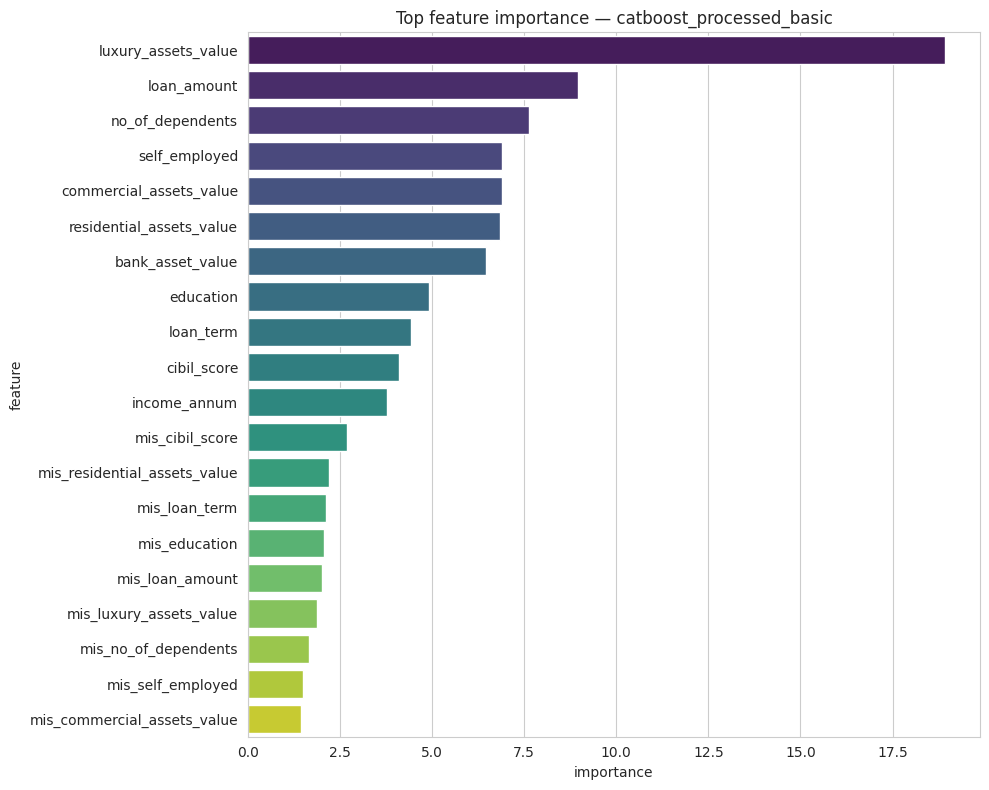

In [ ]:
# Cell: Error review — inspect confusion matrix, high-confidence misses, and feature importance
best_pred_label = (best_oof >= best_threshold).astype(int)
cm = confusion_matrix(train_df[TARGET_COL].astype(int), best_pred_label)
cm_df = pd.DataFrame(cm, index=["actual_0", "actual_1"], columns=["pred_0", "pred_1"])
display(cm_df)

error_review_df = oof_df.copy()
error_review_df["error"] = (
    error_review_df["y_true"] != error_review_df["pred_label_best"]
).astype(int)
error_review_df["confidence"] = np.where(
    error_review_df["pred_label_best"] == 1,
    error_review_df["pred_proba"],
    1.0 - error_review_df["pred_proba"],
)

hard_errors = (
    error_review_df[error_review_df["error"] == 1]
    .sort_values("confidence", ascending=False)
    .head(10)
)
print("Top high-confidence mistakes:")
display(hard_errors)

if len(fi_summary):
    top_features = fi_summary[fi_summary["experiment"] == best_exp].head(20)
    display(top_features)
    plt.figure(figsize=(10, 8))
    sns.barplot(data=top_features, x="importance", y="feature", palette="viridis")
    plt.title(f"Top feature importance — {best_exp}")
    plt.tight_layout()
    plt.show()

## Submission

The last cell keeps Kaggle-native submission behavior. If credentials are available and `RUN_SUBMISSION` is enabled, the notebook will submit the CSV we just created.

In [18]:
# Cell: Submission — send the final CSV to Kaggle when runtime flags allow it
if RUN_SUBMISSION:
    if api is None:
        raise RuntimeError("RUN_SUBMISSION=True but Kaggle API auth is not available")

    submit_message = (
        f"{NOTEBOOK_SLUG} | "
        f"cv_mode={CV_MODE} n_splits={N_SPLITS} seed={SEED} | "
        f"time={datetime.now(UTC).isoformat()}"
    )
    api.competition_submit(
        file_name=str(OUTPUT_ROOT / f"submission_{NOTEBOOK_SLUG}.csv"),
        message=submit_message,
        competition=COMPETITION,
    )
    print("Submission sent:", submit_message)
else:
    print("RUN_SUBMISSION is False, so the submission file was created but not sent.")

100%|██████████| 62.5k/62.5k [00:00<00:00, 159kB/s]


Submission sent: loan23-03-human-eda-gpu-fast | cv_mode=stratified n_splits=5 seed=42 | time=2026-03-21T14:21:23.419426+00:00
